In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

In [ ]:
path_to_csv = r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\car-sales-extended-missing-data.csv'

df = pd.read_csv(path_to_csv)

In [ ]:
df

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
cols_num = ['Odometer (KM)', 'Price']
df[cols_num]

In [ ]:
df[cols_num].hist(color="#0B9EB1", bins=50);

In [ ]:
from sklearn.ensemble import IsolationForest
iso_f = IsolationForest(n_estimators=200, contamination=0.10)
pred = iso_f.fit_predict(df['Price'].to_frame())
mask = pred == -1

In [ ]:
df[mask]

In [ ]:
plt.hist(df.loc[mask, 'Price'], bins=100, color='#FF7F7F')
plt.hist(df.loc[~mask, 'Price'], bins=100, color='lightgreen')
plt.show()

In [ ]:
# m = df['Price'].median()
q1, m, q3 = df['Price'].quantile([0.25,0.5, 0.75])

iqr = np.abs(q1 - q3)
lower_limit = q1 - 1.5*iqr 
upper_limit = q3 + 1.5*iqr 

upper_outlier = df['Price'] > upper_limit
lower_outlier = df['Price'] < lower_limit

outlier_mask = upper_outlier | lower_outlier
df.loc[outlier_mask, 'Price'].hist(bins=50, color="#FF0000")
df.loc[~outlier_mask, 'Price'].hist(bins=50, color='#54ff45')
plt.show()

In [ ]:
df2 = df.loc[~outlier_mask]

In [ ]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

### 16/02/2026

In [ ]:
from sklearn.preprocessing import TargetEncoder

t_enc = TargetEncoder(smooth=0, cv=2)
outp = t_enc.fit_transform(df2[['Make']], df2['Price'])

np.unique(outp)


## other way .transform

In [ ]:
df3 = pd.read_csv(r'C:\Users\konta\Documents\DIV_Academy\Module2(From_29_nov)\data\housing.csv')

In [ ]:
df3

In [ ]:
df3_num = df3.select_dtypes(include='number')
df3_num.hist(figsize=(12, 16), bins=100, color="#12ddaa");

In [ ]:
### Standard scaling

fig, axs = plt.subplots(nrows=2, ncols=2)
axs[0, 0].hist(df3['median_income'], bins=50);
axs[0, 1].hist();

C:\Users\konta\AppData\Local\Temp\ipykernel_20232\254068785.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


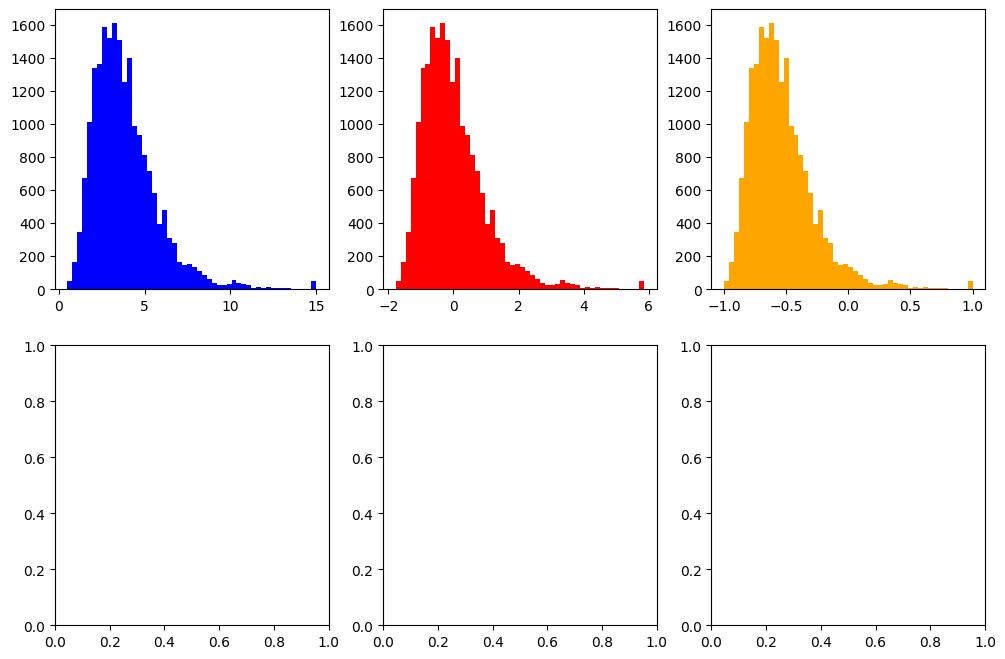

In [38]:
### inputers
### feature scaling
### standard scaling

from sklearn.preprocessing import StandardScaler, MinMaxScaler
ss = StandardScaler()
output_ss = ss.fit_transform(df3[['median_income']])
mm = MinMaxScaler(feature_range=(-1,1))
output_mm = mm.fit_transform(df3[['median_income']])

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12,8))
axs[0,0].hist(df3['median_income'], bins=50, color='blue')
axs[0,1].hist(output_ss, bins=50, color='red')
axs[0,2].hist(output_mm, bins=50, color='orange')
fig.show()